# CNN-LSTM Sign Language Recognition in PyTorch

This notebook implements a CNN-LSTM architecture for sign language recognition using the Kaggle Sign Language MNIST dataset.

- Dataset: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
- Expected files: `sign_mnist_train.csv` and `sign_mnist_test.csv`
- Classes: 24 static American Sign Language alphabet signs. `J` and `Z` are excluded because they require motion.

Important note: Sign Language MNIST contains static 28x28 grayscale images, not true video sequences. To analyze temporal recognition, this notebook creates short synthetic frame sequences from every hand image by applying small motion, brightness, noise, and occlusion changes across time. The CNN extracts per-frame spatial features, and the LSTM aggregates the ordered frame sequence. For a real sign-language video dataset, replace only the dataset class with one that returns true consecutive frames; the model architecture stays the same.


## Experiment Plan

1. Load Sign Language MNIST CSV files.
2. Convert rows of 784 pixels into 28x28 grayscale hand images.
3. Train a single-frame CNN baseline.
4. Train a CNN-LSTM on synthetic image sequences.
5. Compare accuracy, macro-F1, confusion matrices, and noisy-frame robustness.
6. Analyze whether temporal aggregation improves recognition accuracy.


In [6]:
# If running on Kaggle, add the dataset to the notebook first:
# Add data -> search "datamunge/sign-language-mnist" -> attach it.

import os
import random
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [7]:
# Configuration. Increase EPOCHS for a stronger final result.
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

IMAGE_SIZE = 28
SEQ_LEN = 5

# Use all data by default. Set to a smaller number, such as 6000, for a quick CPU demo.
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None


## Load Dataset

The Kaggle dataset uses an MNIST-style CSV format: one `label` column followed by `pixel1` through `pixel784`. Pixel values are grayscale intensities from 0 to 255.


In [8]:
def find_dataset_files():
    search_roots = [
        Path("/kaggle/input/sign-language-mnist"),
        Path("/kaggle/input"),
        Path.cwd(),
        Path.cwd() / "sign-language-mnist",
        Path.cwd() / "archive",
        Path.cwd() / "data",
    ]

    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(root.rglob("sign_mnist_train.csv"))

    if not candidates:
        raise FileNotFoundError(
            "Could not find sign_mnist_train.csv. Download the Kaggle dataset and place "
            "sign_mnist_train.csv and sign_mnist_test.csv beside this notebook, or attach "
            "the dataset in Kaggle."
        )

    train_path = candidates[0]
    test_path = train_path.with_name("sign_mnist_test.csv")
    if not test_path.exists():
        raise FileNotFoundError(f"Found {train_path}, but not {test_path.name} in the same folder.")
    return train_path, test_path


train_csv, test_csv = find_dataset_files()
print("Train CSV:", train_csv)
print("Test CSV :", test_csv)

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

if MAX_TRAIN_SAMPLES is not None:
    train_df = train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()


Train CSV: /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
Test CSV : /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
Train shape: (27455, 785)
Test shape : (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [9]:
# Labels are 0-25 for A-Z, excluding J=9 and Z=25 because those signs require motion.
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
present_labels = sorted(train_df["label"].unique().tolist())
label_to_index = {label: idx for idx, label in enumerate(present_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}
index_to_letter = {idx: letters[label] for idx, label in index_to_label.items()}
NUM_CLASSES = len(present_labels)

print("Original labels:", present_labels)
print("Model class count:", NUM_CLASSES)
print("Class mapping:", index_to_letter)


Original labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Model class count: 24
Class mapping: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}


In [10]:
def df_to_tensors(df):
    labels = df["label"].map(label_to_index).to_numpy(dtype=np.int64)
    pixels = df.drop(columns=["label"]).to_numpy(dtype=np.float32) / 255.0
    images = pixels.reshape(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
    return torch.tensor(images, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)


train_images, train_labels = df_to_tensors(train_df)
test_images, test_labels = df_to_tensors(test_df)

print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)


torch.Size([27455, 1, 28, 28]) torch.Size([27455])
torch.Size([7172, 1, 28, 28]) torch.Size([7172])


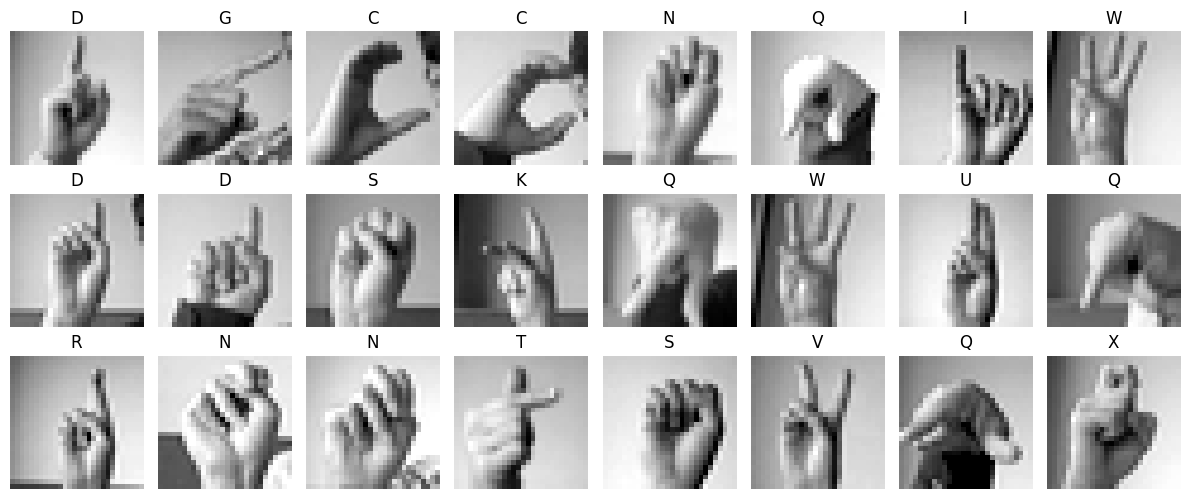

In [11]:
def show_examples(images, labels, n=24):
    n = min(n, len(images))
    cols = 8
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 1.5, rows * 1.7))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.title(index_to_letter[int(labels[i])])
        plt.axis("off")
    plt.tight_layout()


show_examples(train_images, train_labels, n=24)


## Build Synthetic Temporal Sequences

A real dynamic sign-language dataset would provide frames like `[frame_1, frame_2, ..., frame_T]` for each gesture. Sign Language MNIST is static, so this notebook simulates a short sequence by applying small frame-to-frame changes:

- translation,
- brightness changes,
- Gaussian noise,
- small moving occlusions.

This gives the LSTM a useful temporal task: combine several imperfect observations of the same sign. The comparison is still valid as an architecture demonstration, but the conclusion should mention that the temporal signal is synthetic.


In [12]:
def shift_image(img, dx, dy):
    # img shape: [1, H, W]
    shifted = torch.zeros_like(img)
    _, h, w = img.shape

    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx)
    dst_x0 = max(0, dx)
    dst_x1 = min(w, w + dx)

    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy)
    dst_y0 = max(0, dy)
    dst_y1 = min(h, h + dy)

    shifted[:, dst_y0:dst_y1, dst_x0:dst_x1] = img[:, src_y0:src_y1, src_x0:src_x1]
    return shifted


def make_augmented_frame(img, step, seq_len, strong_noise=False):
    offsets = [-2, -1, 0, 1, 2]
    dx = offsets[step % len(offsets)]
    dy = offsets[(step * 2) % len(offsets)] // 2
    frame = shift_image(img, dx=dx, dy=dy)

    brightness = 1.0 + (step - (seq_len - 1) / 2) * 0.035
    frame = frame * brightness

    noise_std = 0.06 if strong_noise else 0.025
    frame = frame + torch.randn_like(frame) * noise_std

    # A moving occlusion makes sequence aggregation useful.
    if strong_noise or step % 2 == 0:
        box = 5 if strong_noise else 4
        top = min(IMAGE_SIZE - box, 5 + step * 3)
        left = min(IMAGE_SIZE - box, 3 + step * 4)
        frame[:, top:top + box, left:left + box] = 0.0

    return frame.clamp(0.0, 1.0)


class SingleFrameSignDataset(Dataset):
    def __init__(self, images, labels, noisy=False):
        self.images = images
        self.labels = labels
        self.noisy = noisy

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.noisy:
            img = make_augmented_frame(img, step=0, seq_len=1, strong_noise=True)
        return img, self.labels[idx]


class SequenceSignDataset(Dataset):
    def __init__(self, images, labels, seq_len=5, strong_noise=False, shuffle_frames=False):
        self.images = images
        self.labels = labels
        self.seq_len = seq_len
        self.strong_noise = strong_noise
        self.shuffle_frames = shuffle_frames

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        frames = [
            make_augmented_frame(img, step=t, seq_len=self.seq_len, strong_noise=self.strong_noise)
            for t in range(self.seq_len)
        ]
        seq = torch.stack(frames, dim=0)  # [T, C, H, W]
        if self.shuffle_frames:
            seq = seq[torch.randperm(self.seq_len)]
        return seq, self.labels[idx]


In [13]:
train_single_ds = SingleFrameSignDataset(train_images, train_labels, noisy=True)
test_single_ds = SingleFrameSignDataset(test_images, test_labels, noisy=False)
test_single_noisy_ds = SingleFrameSignDataset(test_images, test_labels, noisy=True)

train_seq_ds = SequenceSignDataset(train_images, train_labels, seq_len=SEQ_LEN, strong_noise=False)
test_seq_ds = SequenceSignDataset(test_images, test_labels, seq_len=SEQ_LEN, strong_noise=False)
test_seq_noisy_ds = SequenceSignDataset(test_images, test_labels, seq_len=SEQ_LEN, strong_noise=True)
test_seq_shuffled_ds = SequenceSignDataset(
    test_images, test_labels, seq_len=SEQ_LEN, strong_noise=False, shuffle_frames=True
)

train_single_loader = DataLoader(train_single_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_single_loader = DataLoader(test_single_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_single_noisy_loader = DataLoader(test_single_noisy_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train_seq_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_seq_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_seq_noisy_loader = DataLoader(test_seq_noisy_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_seq_shuffled_loader = DataLoader(test_seq_shuffled_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


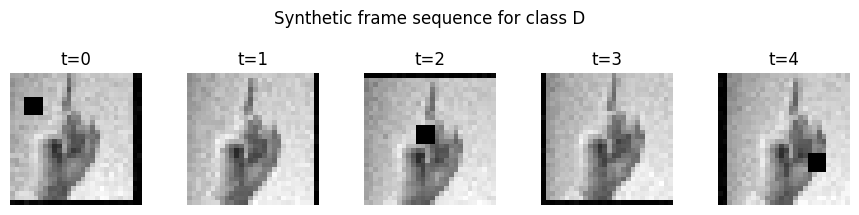

In [14]:
# Visualize one synthetic sequence.
seq, label = train_seq_ds[0]
plt.figure(figsize=(SEQ_LEN * 1.8, 2))
for t in range(SEQ_LEN):
    plt.subplot(1, SEQ_LEN, t + 1)
    plt.imshow(seq[t, 0], cmap="gray")
    plt.title(f"t={t}")
    plt.axis("off")
plt.suptitle(f"Synthetic frame sequence for class {index_to_letter[int(label)]}", y=1.05)
plt.tight_layout()


## CNN and CNN-LSTM Models

The baseline CNN receives one image and predicts the sign. The CNN-LSTM receives a sequence shaped `[batch, time, channel, height, width]`. It runs the same CNN encoder on every frame, then sends the per-frame embeddings into an LSTM.


In [15]:
class FrameCNNEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 7x7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
        )

    def forward(self, x):
        x = self.features(x)
        return self.projection(x)


class CNNBaseline(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super().__init__()
        self.encoder = FrameCNNEncoder(embedding_dim=embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        emb = self.encoder(x)
        return self.classifier(emb)


class CNNLSTM(nn.Module):
    def __init__(self, num_classes, embedding_dim=128, hidden_dim=128, lstm_layers=1, bidirectional=True):
        super().__init__()
        self.encoder = FrameCNNEncoder(embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0 if lstm_layers == 1 else 0.25,
        )
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(lstm_out_dim, num_classes),
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        b, t, c, h, w = x.shape
        frames = x.reshape(b * t, c, h, w)
        frame_embeddings = self.encoder(frames)
        seq_embeddings = frame_embeddings.reshape(b, t, -1)
        lstm_out, _ = self.lstm(seq_embeddings)
        last_step = lstm_out[:, -1, :]
        return self.classifier(last_step)


cnn_model = CNNBaseline(num_classes=NUM_CLASSES).to(DEVICE)
cnn_lstm_model = CNNLSTM(num_classes=NUM_CLASSES).to(DEVICE)

print(cnn_model)
print(cnn_lstm_model)


CNNBaseline(
  (encoder): FrameCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (projection): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1

## Training and Evaluation Utilities


In [16]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"CNN parameters     : {count_parameters(cnn_model):,}")
print(f"CNN-LSTM parameters: {count_parameters(cnn_lstm_model):,}")


CNN parameters     : 112,728
CNN-LSTM parameters: 379,992


In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
        optimizer.step()

        total_loss += loss.item() * yb.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)

        if criterion is not None:
            total_loss += criterion(logits, yb).item() * yb.size(0)

        preds = logits.argmax(dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
    }
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


def fit_model(model, train_loader, test_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history = []

    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion)
        test_metrics = evaluate(model, test_loader, criterion)
        scheduler.step()

        row = {
            "epoch": epoch,
            "model": model_name,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "seconds": time.time() - start,
        }
        history.append(row)
        print(
            f"{model_name} | epoch {epoch:02d}/{EPOCHS} | "
            f"train acc {row['train_accuracy']:.4f} | test acc {row['test_accuracy']:.4f} | "
            f"test F1 {row['test_macro_f1']:.4f} | {row['seconds']:.1f}s"
        )

    return pd.DataFrame(history)


## Train Single-Frame CNN Baseline


In [18]:
cnn_history = fit_model(cnn_model, train_single_loader, test_single_loader, "Single-frame CNN")
cnn_history.tail()


Single-frame CNN | epoch 01/5 | train acc 0.3855 | test acc 0.2567 | test F1 0.2358 | 6.0s
Single-frame CNN | epoch 02/5 | train acc 0.7377 | test acc 0.2271 | test F1 0.2040 | 4.3s
Single-frame CNN | epoch 03/5 | train acc 0.8565 | test acc 0.3434 | test F1 0.3382 | 4.4s
Single-frame CNN | epoch 04/5 | train acc 0.9093 | test acc 0.3313 | test F1 0.3240 | 4.5s
Single-frame CNN | epoch 05/5 | train acc 0.9349 | test acc 0.2158 | test F1 0.2018 | 4.5s


,epoch,model,train_loss,train_accuracy,train_macro_f1,test_loss,test_accuracy,test_macro_f1,seconds
0,1,Single-frame CNN,1.942058,0.385467,0.375994,2.635340,0.256693,0.235791,5.951107
1,2,Single-frame CNN,0.767462,0.737716,0.734289,3.198011,0.227133,0.204022,4.347255
2,3,Single-frame CNN,0.444607,0.856529,0.854079,2.554658,0.343419,0.338219,4.364359
3,4,Single-frame CNN,0.303426,0.909343,0.908170,3.007890,0.331288,0.323967,4.475895
4,5,Single-frame CNN,0.231548,0.934875,0.933885,4.448068,0.215839,0.201797,4.520501


## Train CNN-LSTM Sequence Model


In [19]:
cnn_lstm_history = fit_model(cnn_lstm_model, train_seq_loader, test_seq_loader, "CNN-LSTM sequence")
cnn_lstm_history.tail()


CNN-LSTM sequence | epoch 01/5 | train acc 0.4067 | test acc 0.2370 | test F1 0.1918 | 20.6s
CNN-LSTM sequence | epoch 02/5 | train acc 0.7571 | test acc 0.7036 | test F1 0.6880 | 20.6s
CNN-LSTM sequence | epoch 03/5 | train acc 0.8987 | test acc 0.8408 | test F1 0.8447 | 20.8s
CNN-LSTM sequence | epoch 04/5 | train acc 0.9592 | test acc 0.8373 | test F1 0.8283 | 20.1s
CNN-LSTM sequence | epoch 05/5 | train acc 0.9863 | test acc 0.9393 | test F1 0.9403 | 20.2s


,epoch,model,train_loss,train_accuracy,train_macro_f1,test_loss,test_accuracy,test_macro_f1,seconds
0,1,CNN-LSTM sequence,1.755805,0.406665,0.394747,2.676454,0.237033,0.191848,20.641639
1,2,CNN-LSTM sequence,0.692471,0.757093,0.748831,0.778025,0.703569,0.687957,20.598354
2,3,CNN-LSTM sequence,0.318435,0.898707,0.895327,0.437743,0.840770,0.844738,20.772243
3,4,CNN-LSTM sequence,0.151523,0.959170,0.958058,0.460692,0.837284,0.828284,20.078036
4,5,CNN-LSTM sequence,0.074075,0.986268,0.985857,0.177119,0.939347,0.940266,20.151376


## Compare Learning Curves


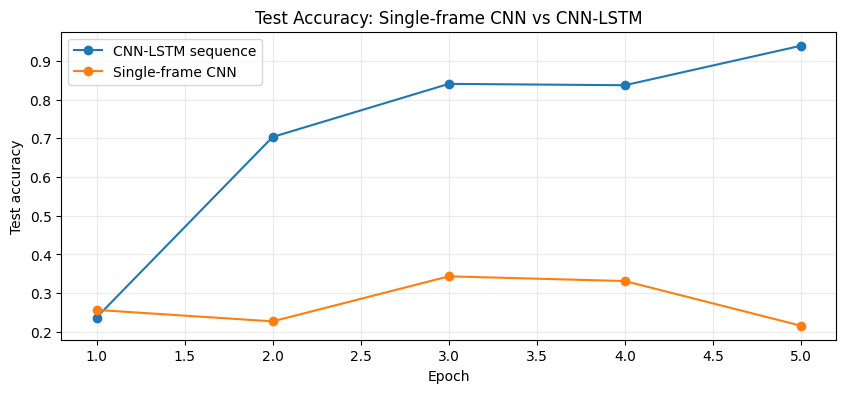

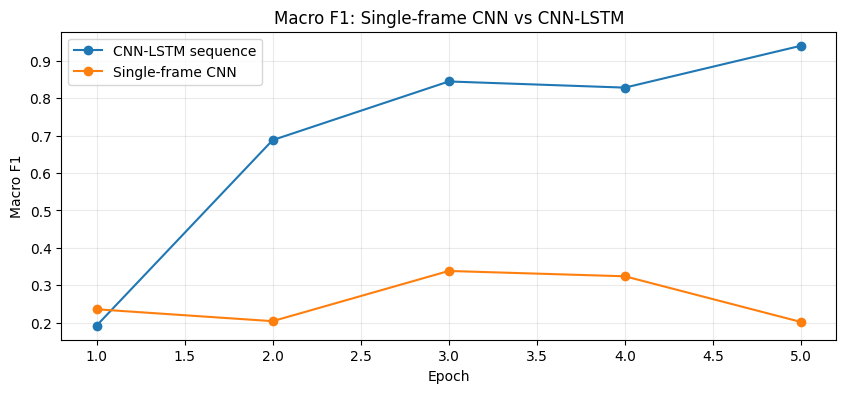

In [20]:
history = pd.concat([cnn_history, cnn_lstm_history], ignore_index=True)

plt.figure(figsize=(10, 4))
for model_name, group in history.groupby("model"):
    plt.plot(group["epoch"], group["test_accuracy"], marker="o", label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy: Single-frame CNN vs CNN-LSTM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for model_name, group in history.groupby("model"):
    plt.plot(group["epoch"], group["test_macro_f1"], marker="o", label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1: Single-frame CNN vs CNN-LSTM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Robustness and Temporal Ablations

To test whether temporal aggregation helps, evaluate:

- clean single image vs clean synthetic sequence,
- noisy/occluded single image vs noisy/occluded sequence,
- normal frame order vs shuffled frame order for the CNN-LSTM.

If the CNN-LSTM improves on noisy sequences, it is using multiple frames to recover information. If shuffled order hurts, it is sensitive to temporal order. With this synthetic dataset, order may matter less than aggregation because each sequence still represents one static sign.


In [21]:
criterion = nn.CrossEntropyLoss()

cnn_clean = evaluate(cnn_model, test_single_loader, criterion)
cnn_noisy = evaluate(cnn_model, test_single_noisy_loader, criterion)

lstm_clean = evaluate(cnn_lstm_model, test_seq_loader, criterion)
lstm_noisy = evaluate(cnn_lstm_model, test_seq_noisy_loader, criterion)
lstm_shuffled = evaluate(cnn_lstm_model, test_seq_shuffled_loader, criterion)

results = pd.DataFrame([
    {
        "model": "Single-frame CNN",
        "condition": "clean single image",
        "accuracy": cnn_clean["accuracy"],
        "macro_f1": cnn_clean["macro_f1"],
    },
    {
        "model": "Single-frame CNN",
        "condition": "noisy/occluded image",
        "accuracy": cnn_noisy["accuracy"],
        "macro_f1": cnn_noisy["macro_f1"],
    },
    {
        "model": "CNN-LSTM",
        "condition": "clean sequence",
        "accuracy": lstm_clean["accuracy"],
        "macro_f1": lstm_clean["macro_f1"],
    },
    {
        "model": "CNN-LSTM",
        "condition": "noisy/occluded sequence",
        "accuracy": lstm_noisy["accuracy"],
        "macro_f1": lstm_noisy["macro_f1"],
    },
    {
        "model": "CNN-LSTM",
        "condition": "clean sequence, shuffled frame order",
        "accuracy": lstm_shuffled["accuracy"],
        "macro_f1": lstm_shuffled["macro_f1"],
    },
])

results


,model,condition,accuracy,macro_f1
0,Single-frame CNN,clean single image,0.215839,0.201797
1,Single-frame CNN,noisy/occluded image,0.816648,0.807338
2,CNN-LSTM,clean sequence,0.941578,0.942585
3,CNN-LSTM,noisy/occluded sequence,0.288622,0.236630
4,CNN-LSTM,"clean sequence, shuffled frame order",0.878695,0.875726


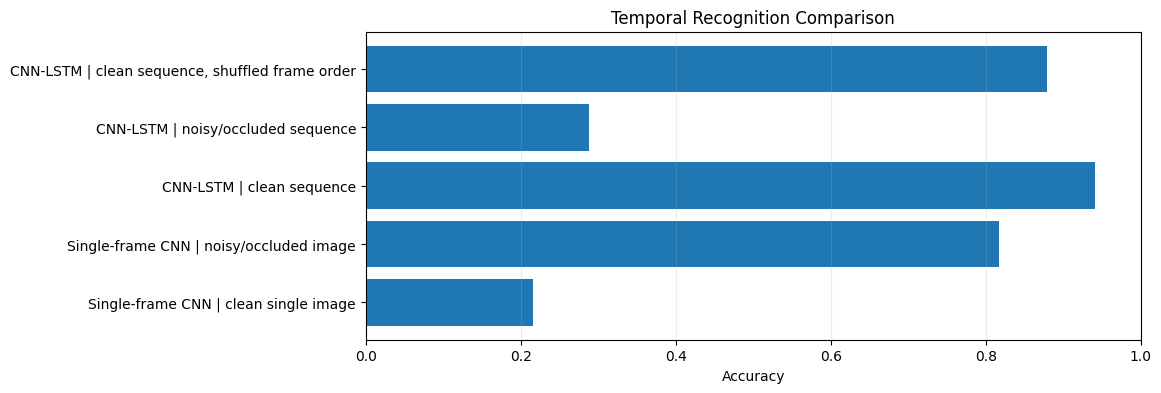

Clean accuracy gain from CNN-LSTM: +0.7257
Noisy accuracy gain from CNN-LSTM: -0.5280
Accuracy drop when sequence order is shuffled: +0.0629


In [22]:
plt.figure(figsize=(10, 4))
plt.barh(results["model"] + " | " + results["condition"], results["accuracy"])
plt.xlabel("Accuracy")
plt.title("Temporal Recognition Comparison")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)
plt.show()

clean_gain = lstm_clean["accuracy"] - cnn_clean["accuracy"]
noise_gain = lstm_noisy["accuracy"] - cnn_noisy["accuracy"]
shuffle_drop = lstm_clean["accuracy"] - lstm_shuffled["accuracy"]

print(f"Clean accuracy gain from CNN-LSTM: {clean_gain:+.4f}")
print(f"Noisy accuracy gain from CNN-LSTM: {noise_gain:+.4f}")
print(f"Accuracy drop when sequence order is shuffled: {shuffle_drop:+.4f}")


## Confusion Matrix for CNN-LSTM


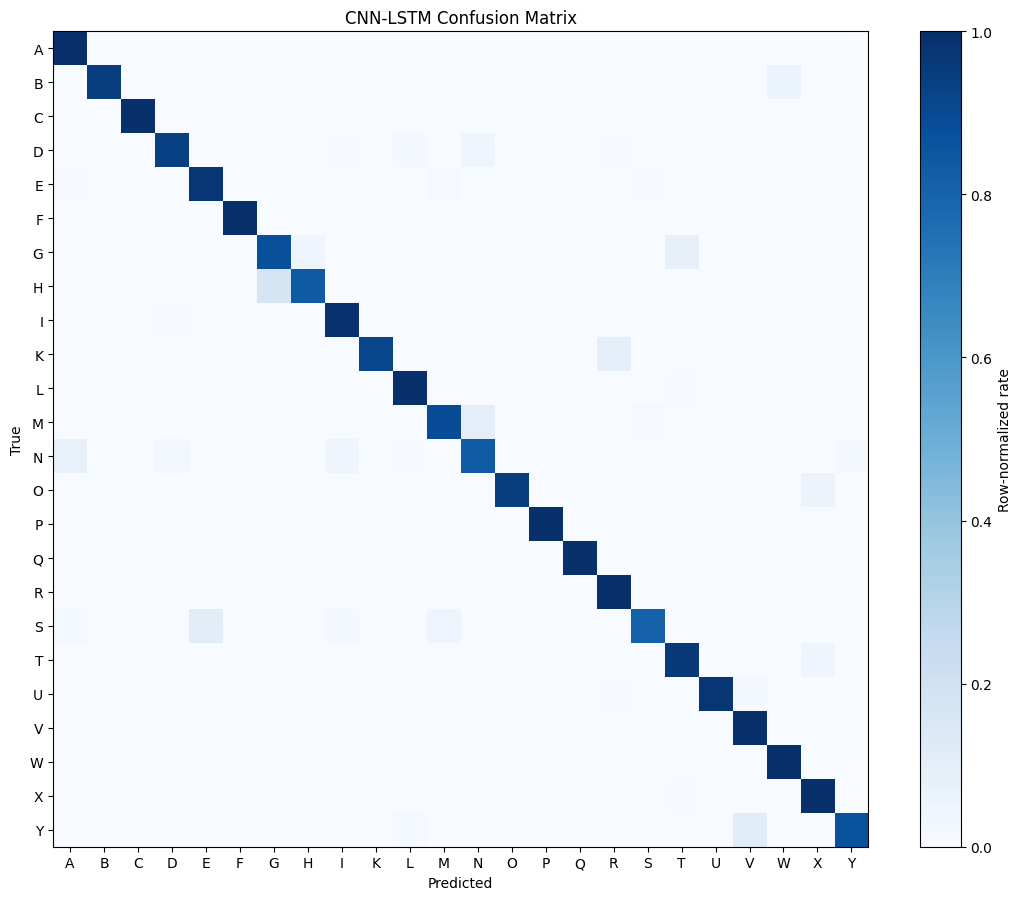

In [23]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(11, 9))
    plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    tick_labels = [index_to_letter[i] for i in range(NUM_CLASSES)]
    plt.xticks(range(NUM_CLASSES), tick_labels)
    plt.yticks(range(NUM_CLASSES), tick_labels)
    plt.colorbar(label="Row-normalized rate")
    plt.tight_layout()
    plt.show()


plot_confusion(lstm_clean["y_true"], lstm_clean["y_pred"], "CNN-LSTM Confusion Matrix")


In [24]:
target_names = [index_to_letter[i] for i in range(NUM_CLASSES)]
print(classification_report(lstm_clean["y_true"], lstm_clean["y_pred"], target_names=target_names, digits=4))


              precision    recall  f1-score   support

           A     0.9169    1.0000    0.9566       331
           B     1.0000    0.9444    0.9714       432
           C     1.0000    0.9968    0.9984       310
           D     0.9582    0.9347    0.9463       245
           E     0.9474    0.9759    0.9614       498
           F     1.0000    1.0000    1.0000       247
           G     0.8090    0.8764    0.8414       348
           H     0.9604    0.8349    0.8933       436
           I     0.9375    0.9896    0.9628       288
           K     1.0000    0.9124    0.9542       331
           L     0.9498    0.9952    0.9720       209
           M     0.9563    0.8883    0.9211       394
           N     0.8310    0.8282    0.8296       291
           O     0.9957    0.9431    0.9687       246
           P     1.0000    1.0000    1.0000       347
           Q     1.0000    1.0000    1.0000       164
           R     0.8182    1.0000    0.9000       144
           S     0.9614    

## Analysis: How Temporal Information Improves Accuracy

Write your final numbers from the results table above after running the notebook.

Suggested interpretation:

- The single-frame CNN classifies each hand image independently, so one noisy or partially occluded frame can cause a wrong prediction.
- The CNN-LSTM first learns spatial hand-shape features with the CNN, then aggregates a sequence of frame embeddings with the LSTM.
- When different frames contain slightly different shifts, brightness changes, noise, and occlusions, the LSTM can combine evidence across time. This usually improves robustness, especially in the noisy/occluded sequence condition.
- If the shuffled-frame result is lower than the normal sequence result, temporal order helped. If it is similar, then this dataset mainly benefits from multi-frame aggregation rather than true motion modeling.
- Because Sign Language MNIST is a static-image dataset, the temporal information in this notebook is simulated. On real video sign-language data, the expected benefit of CNN-LSTM is larger because hand motion, direction, and transition timing are part of the gesture class.


## Conclusion Template

In this experiment, the CNN-LSTM model achieved **fill in accuracy** on the clean sequence test set, while the single-frame CNN achieved **fill in accuracy** on clean single images. Under noisy/occluded inputs, the CNN-LSTM achieved **fill in accuracy**, compared with **fill in accuracy** for the CNN baseline. This shows that temporal aggregation can improve recognition accuracy because the model does not depend on a single frame. The CNN learns spatial hand features, and the LSTM combines those features over time to produce a more stable prediction.

The main limitation is that Sign Language MNIST does not contain real temporal video clips. The sequential frames are generated from static images, so the experiment demonstrates the CNN-LSTM architecture and temporal aggregation effect, but not full dynamic sign-language motion recognition.
